## Harmonic-space cross-correlation coefficient of the NPE posterior mean with ground truth

For each redshift bin, plot $r(\ell) = C_{tp}(\ell) / \sqrt{C_{tt}(\ell)\, C_{pp}(\ell)}$ between the NPE posterior-mean map and the true map, where $t$ = true, $p$ = posterior-mean. Computed for (i) the scalar convergence $\kappa$ and (ii) the 2D shear $\gamma = \gamma_1 + i\gamma_2$ (rotation-invariant total-shear cross-power). Follows the convention of Figure 6 of Boruah, Rozo & Fiedorowicz (2022).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from einops import rearrange
from hydra import compose, initialize
from hydra.utils import instantiate

plt.rcParams["font.family"] = "serif"

import lightning as L
from lightning.pytorch.utilities import move_data_to_device

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/home/twhit/blissWL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


**Load the NPE checkpoint:**

In [2]:
ckpt = "/data/scratch/twhit/checkpoints/trained_encoder_dc2.ckpt"

with initialize(config_path="../", version_base=None):
    cfg = compose(
        "config_train_npe",
        {
            "train.pretrained_weights=" + ckpt,
        },
    )

seed = L.seed_everything(cfg.train.seed)

Seed set to 123123


**Configure the test dataloader:**

In [3]:
data_source = instantiate(cfg.train.data_source)
data_source.setup("test")
test_dl = data_source.test_dataloader()

**Load encoder weights:**

In [4]:
encoder = instantiate(cfg.encoder).to(device)
encoder_state_dict = torch.load(cfg.train.pretrained_weights, map_location=device)["state_dict"]
encoder.load_state_dict(encoder_state_dict, strict=False)
encoder = encoder.eval()

/home/twhit/blissWL/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


**Run inference on the test set to collect true and posterior-mean convergence, true and posterior-mean shear, and tile positions:**

In [5]:
torch.manual_seed(0)

num_tiles_per_side = 8
num_bins = 4

shape = (len(test_dl), num_tiles_per_side, num_tiles_per_side, num_bins)
convergence_true = torch.zeros(*shape, device=device)
convergence_pred = torch.zeros(*shape, device=device)
convergence_std = torch.zeros(*shape, device=device)
shear1_true = torch.zeros(*shape, device=device)
shear1_pred = torch.zeros(*shape, device=device)
shear1_std = torch.zeros(*shape, device=device)
shear2_true = torch.zeros(*shape, device=device)
shear2_pred = torch.zeros(*shape, device=device)
shear2_std = torch.zeros(*shape, device=device)
ra = torch.zeros(*shape, device=device)
dec = torch.zeros(*shape, device=device)

i = -1
for b in test_dl:
    i += 1
    print(i)
    batch = move_data_to_device(b, device)

    convergence_true[i] = batch["tile_catalog"]["convergence"].squeeze()
    shear1_true[i] = batch["tile_catalog"]["shear_1"].squeeze()
    shear2_true[i] = batch["tile_catalog"]["shear_2"].squeeze()
    ra[i] = batch["tile_catalog"]["ra"].squeeze()
    dec[i] = batch["tile_catalog"]["dec"].squeeze()

    with torch.no_grad():
        input_lst = [inorm.get_input_tensor(batch) for inorm in encoder.image_normalizers]
        inputs = torch.cat(input_lst, dim=2)

        x_cat_marginal = encoder.net(inputs).squeeze(0)
        shear1_pred[i] = x_cat_marginal[:, :, 0:num_bins].squeeze()
        shear1_std[i] = x_cat_marginal[:, :, num_bins : (2 * num_bins)].exp().sqrt().squeeze()
        shear2_pred[i] = x_cat_marginal[:, :, (2 * num_bins) : (3 * num_bins)].squeeze()
        shear2_std[i] = x_cat_marginal[:, :, (3 * num_bins) : (4 * num_bins)].exp().sqrt().squeeze()
        convergence_pred[i] = x_cat_marginal[:, :, (4 * num_bins) : (5 * num_bins)].squeeze()
        convergence_std[i] = (
            x_cat_marginal[:, :, (5 * num_bins) : (6 * num_bins)].exp().sqrt().squeeze()
        )

0


1
2


3


4


5


...

35


36


37


38


39


**Convergence — $r(\ell)$ on the stitched test-set map:**

Sort the 40 test images spatially by RA/Dec (as in `posteriormeanmaps.ipynb`) to form a single contiguous $64 \times 40$ tile map covering roughly $0.91° \times 0.57°$ at $0.853$ arcmin per tile. Per redshift bin, take a 2D FFT of the stitched $\kappa$ map for both the true and the posterior-mean convergence, radially bin $|\ell|$ in log-spaced shells, and compute $r(\ell) = C_{tp}(\ell) / \sqrt{C_{tt}(\ell)\,C_{pp}(\ell)}$. This reaches $\ell_\text{fund} \approx 2\pi/L \approx 400$ and $\ell_\text{Nyq} \approx \pi/\Delta \approx 12700$.

In [6]:
num_dec_images = 8
num_ra_images = 5

# sort images by dec (rows) then by -ra within each row, mirroring posteriormeanmaps.ipynb
ra_mean = ra[..., 0].mean([1, 2])
dec_mean = dec[..., 0].mean([1, 2])
dec_bins = torch.argsort(dec_mean).view(num_dec_images, num_ra_images)
sorted_indices = torch.zeros_like(dec_bins)
for i in range(num_dec_images):
    ra_in_row = ra_mean[dec_bins[i]]
    sorted_indices[i] = dec_bins[i][torch.argsort(-ra_in_row)]
idx = sorted_indices.flatten()

# stitched TRUE convergence map: (64, 40, num_bins)
convergence_true_stitched = rearrange(
    convergence_true[idx].view(
        num_dec_images, num_ra_images, num_tiles_per_side, num_tiles_per_side, num_bins
    ),
    "h w nh nw b -> (h nh) (w nw) b",
).cpu().numpy().astype(np.float64)

ny, nx = convergence_true_stitched.shape[:2]
print(f"stitched map shape: ({ny}, {nx}) tiles")

tile_slen_arcmin = 0.853
tile_slen_rad = tile_slen_arcmin * np.pi / (180.0 * 60.0)

kx = np.fft.fftfreq(nx, d=tile_slen_rad) * 2 * np.pi
ky = np.fft.fftfreq(ny, d=tile_slen_rad) * 2 * np.pi
ellx, elly = np.meshgrid(kx, ky)
ell_mag = np.sqrt(ellx**2 + elly**2)

ell_fundamental = 2 * np.pi / (max(ny, nx) * tile_slen_rad)
ell_nyquist = np.pi / tile_slen_rad

ell_edges = np.logspace(np.log10(ell_fundamental * 0.9), np.log10(ell_nyquist), 14)
min_modes_per_bin = 10
ell_masks_all = [
    (ell_mag >= ell_edges[i]) & (ell_mag < ell_edges[i + 1])
    for i in range(len(ell_edges) - 1)
]
mode_counts = np.array([int(m.sum()) for m in ell_masks_all])
keep_mask = mode_counts >= min_modes_per_bin
print(f"modes per bin (all): {mode_counts}")
print(f"kept {keep_mask.sum()} / {len(keep_mask)} bins (min {min_modes_per_bin} modes)")

ell_centers_all = np.sqrt(ell_edges[:-1] * ell_edges[1:])
ell_centers = ell_centers_all[keep_mask]
n_ell_kept = len(ell_centers)


def radial_bin(p_2d):
    c = np.zeros(len(ell_centers_all))
    for k, m in enumerate(ell_masks_all):
        if m.any():
            c[k] = p_2d[m].mean()
    return c[keep_mask]


# Draw posterior samples of convergence and stitch each realization
num_samples = 200
torch.manual_seed(0)
conv_samples = torch.distributions.Normal(convergence_pred, convergence_std).sample([num_samples])
convergence_pred_samples_stitched = rearrange(
    conv_samples[:, idx].view(
        num_samples, num_dec_images, num_ra_images,
        num_tiles_per_side, num_tiles_per_side, num_bins,
    ),
    "s h w nh nw b -> s (h nh) (w nw) b",
).cpu().numpy().astype(np.float64)

# Per-sample r_κ(ℓ)
r_ell_samples = np.zeros((num_samples, num_bins, n_ell_kept))
for b in range(num_bins):
    fft_t = np.fft.fft2(convergence_true_stitched[..., b])
    C_tt = radial_bin(np.abs(fft_t) ** 2)
    for s in range(num_samples):
        fft_p = np.fft.fft2(convergence_pred_samples_stitched[s, ..., b])
        C_pp = radial_bin(np.abs(fft_p) ** 2)
        C_tp = radial_bin(np.real(np.conj(fft_t) * fft_p))
        r_ell_samples[s, b] = C_tp / np.sqrt(C_tt * C_pp)

print(f"r_ell_samples shape: {r_ell_samples.shape}")
print(f"ℓ bin centers: {np.array2string(ell_centers, precision=0)}")

stitched map shape: (64, 40) tiles
modes per bin (all): [  2   0   8   4  12  14  30  56  98 160 286 488 830]
kept 9 / 13 bins (min 10 modes)


r_ell_samples shape: (200, 4, 9)
ℓ bin centers: [ 1226.  1613.  2123.  2795.  3678.  4841.  6371.  8385. 11036.]


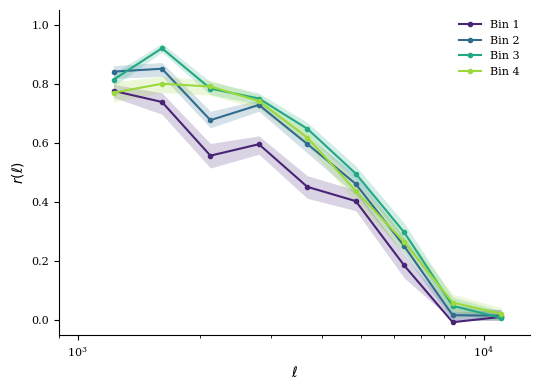

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4))

axislabelsize = 10
ticklabelsize = 8

colors = plt.cm.viridis(np.linspace(0.1, 0.85, num_bins))

for b in range(num_bins):
    p25, p50, p75 = np.percentile(r_ell_samples[:, b, :], [25, 50, 75], axis=0)
    p25 = np.clip(p25, 0, None)
    ax.fill_between(ell_centers, p25, p75, color=colors[b], alpha=0.2, linewidth=0)
    ax.plot(
        ell_centers,
        p50,
        color=colors[b],
        marker="o",
        markersize=3,
        label=f"Bin {b + 1}",
    )

ax.set_xscale("log")
ax.set_xlabel(r"$\ell$", fontsize=axislabelsize)
ax.set_ylabel(r"$r(\ell)$", fontsize=axislabelsize)
ax.set_xlim(900, 13000)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis="both", which="major", labelsize=ticklabelsize)
ax.legend(frameon=False, fontsize=ticklabelsize)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

fig.savefig(
    "figures/crosscorrelation_ell.png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

**Shear — $r(\ell)$ on the stitched test-set map:**

Treat the 2D shear as a complex field $\gamma = \gamma_1 + i\gamma_2$ on the same stitched $64 \times 40$ tile grid. Per redshift bin, compute the 2D FFT of $\gamma_t$ and $\gamma_p$; define $C_{tt}(\ell) = \langle |\tilde\gamma_t|^2 \rangle$, $C_{pp}(\ell) = \langle |\tilde\gamma_p|^2 \rangle$, $C_{tp}(\ell) = \mathrm{Re}\langle \tilde\gamma_t^* \tilde\gamma_p \rangle$ (rotation-invariant total-shear power, E+B), and $r_\gamma(\ell) = C_{tp} / \sqrt{C_{tt}\, C_{pp}}$. Reuses the $\ell$-bin edges and `keep_mask` from the convergence section.

In [8]:
def stitch(x):
    return rearrange(
        x[idx].view(
            num_dec_images, num_ra_images, num_tiles_per_side, num_tiles_per_side, num_bins
        ),
        "h w nh nw b -> (h nh) (w nw) b",
    ).cpu().numpy().astype(np.float64)


def stitch_samples(x):
    return rearrange(
        x[:, idx].view(
            num_samples, num_dec_images, num_ra_images,
            num_tiles_per_side, num_tiles_per_side, num_bins,
        ),
        "s h w nh nw b -> s (h nh) (w nw) b",
    ).cpu().numpy().astype(np.float64)


shear1_true_stitched = stitch(shear1_true)
shear2_true_stitched = stitch(shear2_true)

torch.manual_seed(1)
shear1_samples = torch.distributions.Normal(shear1_pred, shear1_std).sample([num_samples])
shear2_samples = torch.distributions.Normal(shear2_pred, shear2_std).sample([num_samples])
shear1_pred_samples_stitched = stitch_samples(shear1_samples)
shear2_pred_samples_stitched = stitch_samples(shear2_samples)

r_shear_ell_samples = np.zeros((num_samples, num_bins, n_ell_kept))
for b in range(num_bins):
    gamma_t = shear1_true_stitched[..., b] + 1j * shear2_true_stitched[..., b]
    fft_t = np.fft.fft2(gamma_t)
    C_tt = radial_bin(np.abs(fft_t) ** 2)
    for s in range(num_samples):
        gamma_p = (
            shear1_pred_samples_stitched[s, ..., b]
            + 1j * shear2_pred_samples_stitched[s, ..., b]
        )
        fft_p = np.fft.fft2(gamma_p)
        C_pp = radial_bin(np.abs(fft_p) ** 2)
        C_tp = radial_bin(np.real(np.conj(fft_t) * fft_p))
        r_shear_ell_samples[s, b] = C_tp / np.sqrt(C_tt * C_pp)

for b in range(num_bins):
    med = np.median(r_shear_ell_samples[:, b, :], axis=0)
    print(f"bin {b + 1}: median r_γ(ℓ) range = [{med.min():.3f}, {med.max():.3f}]")

bin 1: median r_γ(ℓ) range = [0.005, 0.356]
bin 2: median r_γ(ℓ) range = [0.005, 0.339]
bin 3: median r_γ(ℓ) range = [0.015, 0.359]
bin 4: median r_γ(ℓ) range = [0.015, 0.324]


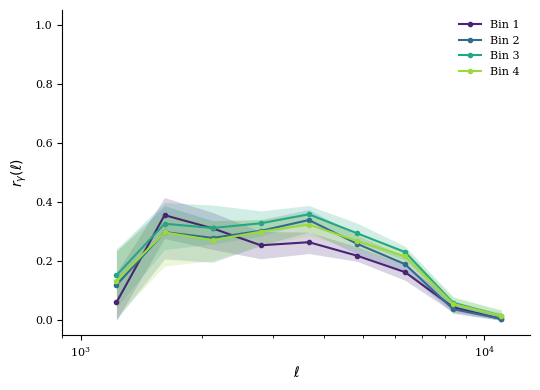

In [9]:
fig, ax = plt.subplots(figsize=(5.5, 4))

axislabelsize = 10
ticklabelsize = 8

for b in range(num_bins):
    p25, p50, p75 = np.percentile(r_shear_ell_samples[:, b, :], [25, 50, 75], axis=0)
    p25 = np.clip(p25, 0, None)
    ax.fill_between(ell_centers, p25, p75, color=colors[b], alpha=0.2, linewidth=0)
    ax.plot(
        ell_centers,
        p50,
        color=colors[b],
        marker="o",
        markersize=3,
        label=f"Bin {b + 1}",
    )

ax.set_xscale("log")
ax.set_xlabel(r"$\ell$", fontsize=axislabelsize)
ax.set_ylabel(r"$r_\gamma(\ell)$", fontsize=axislabelsize)
ax.set_xlim(900, 13000)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis="both", which="major", labelsize=ticklabelsize)
ax.legend(frameon=False, fontsize=ticklabelsize)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()

fig.savefig(
    "figures/crosscorrelation_shear_ell.png",
    dpi=600,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

## Tomographic auto- and cross-spectra: posterior-mean vs truth

For each redshift-bin pair $(i, j)$, compute $C^{ij}(\ell)$ for both the true and posterior-mean stitched maps, for convergence $\kappa$ and the complex shear $\gamma = \gamma_1 + i\gamma_2$. Diagonal panels ($i = j$) are auto-spectra; off-diagonal panels are cross-spectra between tomographic bins. This directly tests whether the posterior-mean maps inherit the auto- and cross-correlation structure of the true lensing field.

In [10]:
kappa_t_fft = [np.fft.fft2(convergence_true_stitched[..., b]) for b in range(num_bins)]
gamma_t_fft = [
    np.fft.fft2(shear1_true_stitched[..., b] + 1j * shear2_true_stitched[..., b])
    for b in range(num_bins)
]


def cross_matrix_from_ffts(fft_list):
    return [
        [radial_bin(np.real(np.conj(fft_list[i]) * fft_list[j])) for j in range(num_bins)]
        for i in range(num_bins)
    ]


C_kappa_t = cross_matrix_from_ffts(kappa_t_fft)
C_gamma_t = cross_matrix_from_ffts(gamma_t_fft)

C_kappa_p_samples = np.zeros((num_samples, num_bins, num_bins, n_ell_kept))
C_gamma_p_samples = np.zeros((num_samples, num_bins, num_bins, n_ell_kept))

for s in range(num_samples):
    kappa_p_fft_s = [
        np.fft.fft2(convergence_pred_samples_stitched[s, ..., b]) for b in range(num_bins)
    ]
    gamma_p_fft_s = [
        np.fft.fft2(
            shear1_pred_samples_stitched[s, ..., b]
            + 1j * shear2_pred_samples_stitched[s, ..., b]
        )
        for b in range(num_bins)
    ]
    for i in range(num_bins):
        for j in range(num_bins):
            C_kappa_p_samples[s, i, j] = radial_bin(
                np.real(np.conj(kappa_p_fft_s[i]) * kappa_p_fft_s[j])
            )
            C_gamma_p_samples[s, i, j] = radial_bin(
                np.real(np.conj(gamma_p_fft_s[i]) * gamma_p_fft_s[j])
            )

# Flat-sky normalization: C(ℓ) = (Δθ_pix² / N_total) · ⟨|FFT|²⟩, in steradians
spectrum_norm = tile_slen_rad ** 2 / (ny * nx)
C_kappa_t = [[np.array(c) * spectrum_norm for c in row] for row in C_kappa_t]
C_gamma_t = [[np.array(c) * spectrum_norm for c in row] for row in C_gamma_t]
C_kappa_p_samples *= spectrum_norm
C_gamma_p_samples *= spectrum_norm

print(f"spectrum_norm = {spectrum_norm:.3e} sr")
print(f"C_kappa_p_samples shape: {C_kappa_p_samples.shape}")
print(f"C_gamma_p_samples shape: {C_gamma_p_samples.shape}")

spectrum_norm = 2.405e-11 sr
C_kappa_p_samples shape: (200, 4, 4, 9)
C_gamma_p_samples shape: (200, 4, 4, 9)


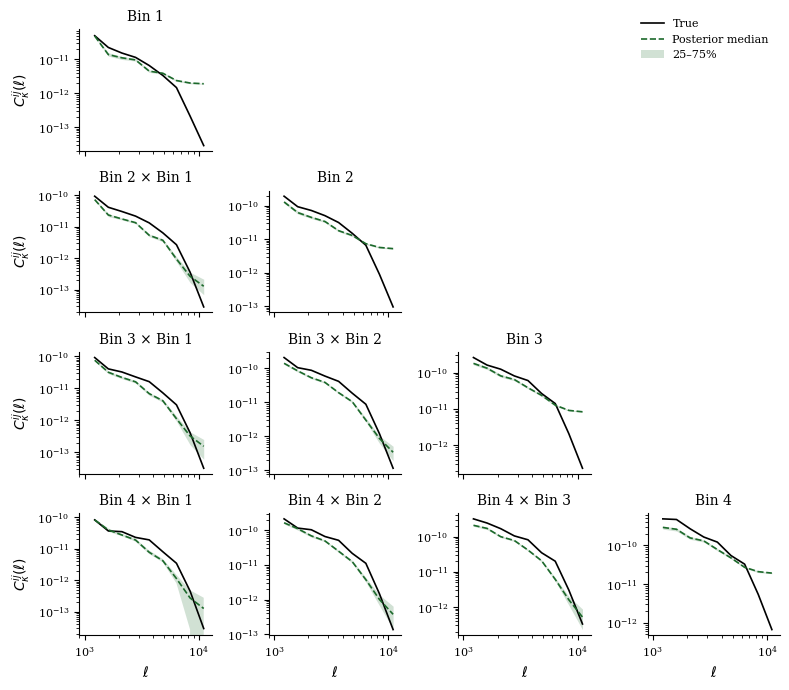

In [11]:
def plot_spectra_matrix(C_true, C_pred_samples, ylabel, outpath):
    posterior_color = "#1c692b"
    axislabelsize = 10
    ticklabelsize = 8
    fig, axes = plt.subplots(num_bins, num_bins, figsize=(8, 7), sharex=True)
    for i in range(num_bins):
        for j in range(num_bins):
            ax = axes[i, j]
            if j > i:
                ax.axis("off")
                continue
            t = np.array(C_true[i][j])
            p25, p50, p75 = np.percentile(
                C_pred_samples[:, i, j, :], [25, 50, 75], axis=0
            )
            p25 = np.clip(p25, 0, None)
            t_pos = t > 0
            if t_pos.any():
                ax.loglog(
                    ell_centers[t_pos], t[t_pos],
                    color="black", linewidth=1.2, label="True",
                )
            p50_pos = p50 > 0
            if p50_pos.any():
                ax.loglog(
                    ell_centers[p50_pos], p50[p50_pos],
                    color=posterior_color, linestyle="--", linewidth=1.2,
                    label="Posterior median",
                )
            band_pos = p75 > 0
            if band_pos.any():
                ax.fill_between(
                    ell_centers[band_pos], p25[band_pos], p75[band_pos],
                    color=posterior_color, alpha=0.2, linewidth=0, label="25–75%",
                )
            ax.set_xlim(900, 13000)
            title = f"Bin {i + 1}" if i == j else f"Bin {i + 1} × Bin {j + 1}"
            ax.set_title(title, fontsize=axislabelsize)
            ax.spines[["top", "right"]].set_visible(False)
            ax.tick_params(axis="both", which="major", labelsize=ticklabelsize)
            if i == num_bins - 1:
                ax.set_xlabel(r"$\ell$", fontsize=axislabelsize)
            if j == 0:
                ax.set_ylabel(ylabel, fontsize=axislabelsize)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="upper right", bbox_to_anchor=(0.98, 0.98),
        fontsize=ticklabelsize, frameon=False,
    )
    fig.tight_layout()
    fig.savefig(outpath, dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)


plot_spectra_matrix(
    C_kappa_t, C_kappa_p_samples,
    ylabel=r"$C_\kappa^{ij}(\ell)$",
    outpath="figures/tomographic_spectra_kappa.png",
)

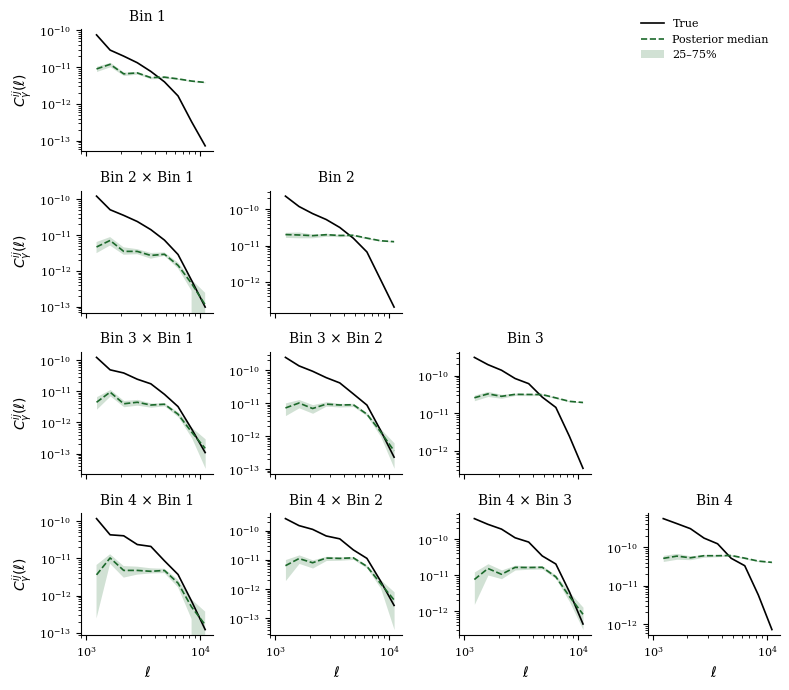

In [12]:
plot_spectra_matrix(
    C_gamma_t, C_gamma_p_samples,
    ylabel=r"$C_\gamma^{ij}(\ell)$",
    outpath="figures/tomographic_spectra_shear.png",
)